# Generative Models: VAEs and Diffusion Models

---
<a id='1'></a>
## 1. What is a Generative Model?

So far in this course we have focused on **discriminative** models — models that learn to distinguish between classes or predict a target value:

$$p(y \mid x) \quad \text{"Given this image, what is the label?"}$$

A **generative model** does something fundamentally different: it learns the underlying **distribution of the data itself**:

$$p(x) \quad \text{"What does a realistic image look like?"}$$

Once you know $p(x)$, you can **sample** from it to create new, previously unseen examples that look like they came from the same distribution.

### Why do we care?

| Application | What's happening |
|---|---|
| **Image generation** (Stable Diffusion, DALL-E) | Sample from $p(\text{image})$ conditioned on a text prompt |
| **Drug discovery** | Sample from $p(\text{molecule})$ to find new compounds |
| **Data augmentation** | Generate synthetic training examples |
| **Representation learning** | Learn compact, meaningful features as a byproduct |
| **Anomaly detection** | Low probability under $p(x)$ → unusual/anomalous |
| **Image editing / inpainting** | Use knowledge of $p(x)$ to fill in missing parts |

### The core challenge

Real-world data lives in extremely high-dimensional spaces (a 256×256 RGB image has $256 \times 256 \times 3 = 196,608$ dimensions), but realistic images occupy only a tiny **manifold** within that space. Learning that manifold is the goal of generative modeling.

---
<a id='2'></a>
## 2. The Latent Space Idea

A central concept in many generative models is the **latent space** — a lower-dimensional space that captures the essential structure of the data.

### Intuition

Consider all possible photos of human faces. A photo might have 50,000+ pixels, but the space of *realistic* faces is controlled by a much smaller number of factors:
- Age
- Skin tone
- Hair color and length
- Facial structure
- Expression
- Lighting direction

Maybe ~50–200 numbers are enough to describe any face. This small set of numbers lives in the **latent space** (also called the bottleneck, embedding, or code).

### The Encoder–Decoder framework

```
High-dim input              Low-dim latent            High-dim output

┌──────────┐              ┌─────────────┐            ┌──────────┐
│  Image   │   Encoder   │  z (latent) │   Decoder  │ Recon.   │
│ (196608) │──────────── │   (128-d)   │────────────│  Image   │
│  dims)   │   (compres) │             │   (expand) │          │
└──────────┘              └─────────────┘            └──────────┘
```

- **Encoder:** Maps data to latent space ($x \rightarrow z$)
- **Decoder:** Maps latent code back to data space ($z \rightarrow \hat{x}$)
- **Latent vector $z$:** The compact representation

For generation, we want: **sample $z$, then run the decoder.**

The question is: *how do we ensure the latent space has good structure for sampling?*

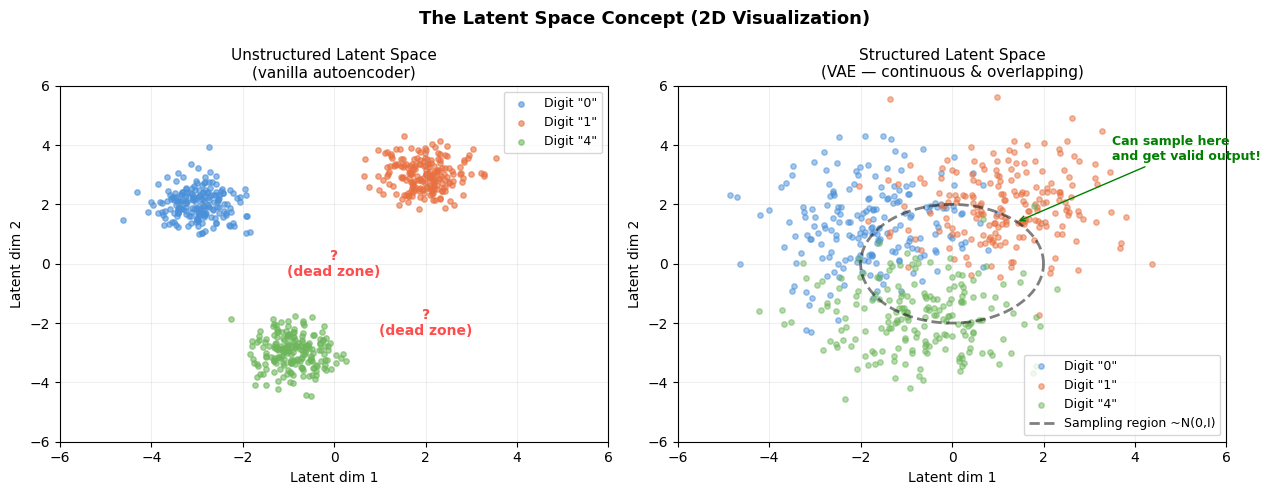

Left:  Sampling from the 'dead zones' produces garbage output.
Right: VAE regularizes latent space so ANY point near the origin
       decodes to something meaningful. This is what makes VAEs generative.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# ─────────────────────────────────────────────────
# Visualize the concept of a latent space
# (simulated, not a real trained model)
# ─────────────────────────────────────────────────

np.random.seed(42)

# Simulate 3 "classes" in a 2D latent space
# Each class clusters in a different region
classes = {
    '0': ([-3, 2],   '#4A90D9', 200),
    '1': ([2, 3],    '#E87040', 200),
    '4': ([-1, -3],  '#6DB65B', 200),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('The Latent Space Concept (2D Visualization)', fontsize=13, fontweight='bold')

# Left: Unstructured latent space (like a basic autoencoder might produce)
ax = axes[0]
ax.set_title('Unstructured Latent Space\n(vanilla autoencoder)', fontsize=11)
for label, (center, color, n) in classes.items():
    # Tight clusters with no overlap
    pts = np.random.randn(n, 2) * 0.5 + center
    ax.scatter(pts[:, 0], pts[:, 1], c=color, s=15, alpha=0.6, label=f'Digit "{label}"')
ax.set_xlabel('Latent dim 1')
ax.set_ylabel('Latent dim 2')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

# Mark "dead zones" between clusters
ax.text(0, 0, '?\n(dead zone)', ha='center', va='center', fontsize=10,
        color='red', fontweight='bold', alpha=0.7)
ax.text(2, -2, '?\n(dead zone)', ha='center', va='center', fontsize=10,
        color='red', fontweight='bold', alpha=0.7)

# Right: Structured latent space (like VAE produces)
ax2 = axes[1]
ax2.set_title('Structured Latent Space\n(VAE — continuous & overlapping)', fontsize=11)
for label, (center, color, n) in classes.items():
    # Broader, overlapping Gaussians centered near origin
    center_vae = [c * 0.6 for c in center]
    pts = np.random.randn(n, 2) * 1.2 + center_vae
    ax2.scatter(pts[:, 0], pts[:, 1], c=color, s=15, alpha=0.5, label=f'Digit "{label}"')

# Draw the standard normal distribution region we sample from
theta = np.linspace(0, 2*np.pi, 100)
ax2.plot(2*np.cos(theta), 2*np.sin(theta), 'k--', linewidth=2, alpha=0.5, label='Sampling region ~N(0,I)')
ax2.set_xlabel('Latent dim 1')
ax2.set_ylabel('Latent dim 2')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)
ax2.set_xlim(-6, 6)
ax2.set_ylim(-6, 6)

ax2.annotate('Can sample here\nand get valid output!', xy=(1.4, 1.4),
             xytext=(3.5, 3.5),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=9, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

print("Left:  Sampling from the 'dead zones' produces garbage output.")
print("Right: VAE regularizes latent space so ANY point near the origin")
print("       decodes to something meaningful. This is what makes VAEs generative.")

---
<a id='3'></a>
## 3. Autoencoders — The Foundation

Before VAEs, there were plain **Autoencoders (AEs)** — neural networks trained to compress data and then reconstruct it.

### Architecture

An autoencoder is just two networks glued together:

1. **Encoder** $q(z|x)$: A neural network that maps input $x$ to a latent code $z$
2. **Decoder** $p(x|z)$: A neural network that maps $z$ back to a reconstruction $\hat{x}$

### Training Objective

Minimize the **reconstruction loss** — how different the output is from the input:

$$\mathcal{L}_{AE} = \|x - \hat{x}\|^2 \quad \text{(Mean Squared Error)}$$

Or for binary inputs (like MNIST):

$$\mathcal{L}_{AE} = -\sum_i [x_i \log \hat{x}_i + (1-x_i) \log(1-\hat{x}_i)] \quad \text{(Binary Cross-Entropy)}$$

### What does the network learn?

The network is forced through a **bottleneck** — the latent space. To minimize reconstruction loss, it must learn to compress the input into the most information-rich representation possible. This makes autoencoders excellent for:

- Dimensionality reduction (like PCA but nonlinear)
- Denoising (train to reconstruct clean images from noisy inputs)
- Anomaly detection (high reconstruction error → unusual input)
- Feature learning

---
<a id='4'></a>
## 4. Why Autoencoders Can't Generate Well

Here's the fundamental problem: **the latent space of a standard autoencoder has no guaranteed structure.**

### The Problem Illustrated

Imagine you train an autoencoder on handwritten digits. After training:
- The encoder has learned to map each digit to some specific point in latent space
- The decoder has learned to reconstruct digits from those specific points

But the encoder could scatter the digits *anywhere* in latent space — it has no incentive to organize them in a consistent or continuous way. The result:

1. **Dead zones:** Most points in latent space don't correspond to any training data. If you sample such a point and run the decoder, you get garbage.

2. **No smooth interpolation:** Moving between two digits in latent space might pass through regions the decoder has never seen, producing nonsensical outputs.

3. **No probability:** We have no idea which regions of latent space are "valid" — there's no $p(z)$ to sample from.

### The Key Insight

For generation, we need:
> **A latent space where ANY sample from a known distribution $p(z)$ produces a valid, realistic output.**

Variational Autoencoders solve this by **imposing structure on the latent space during training.**

---
<a id='5'></a>
## 5. Variational Autoencoders (VAEs)

VAEs were introduced by **Kingma & Welling (2013)** and represent one of the most influential ideas in deep generative modeling.

### The Core Idea in One Sentence

> Instead of mapping each input to a *single point* in latent space, map it to a *probability distribution*, and then sample from that distribution.

### How it works

The VAE encoder doesn't output a vector $z$ directly. It outputs **two vectors**:
- $\mu$ (mu): the **mean** of a Gaussian distribution
- $\sigma$ (sigma) or $\log \sigma^2$: the **variance** of that Gaussian distribution

Then we **sample** from this distribution to get $z$:

$$z \sim \mathcal{N}(\mu, \sigma^2)$$

The decoder then takes this *sampled* $z$ and produces the reconstruction.

### Why does this help?

By encoding each input as a *distribution* rather than a *point*, the model is forced to be robust: the decoder must handle not just the exact mean $\mu$ but any point nearby (within the distribution's spread). This encourages the latent space to be **smooth and continuous** — nearby points in latent space produce similar outputs.

```
                     μ ───────────────────────────────────────────────────────────┐
x ─── Encoder ───┤                              z ~ N(μ, σ²) ─── Decoder ─── x̂
                     log σ² ────────────────────────────────────────────────────┘
```

### The probabilistic perspective

From a Bayesian viewpoint, VAEs define:
- **Prior:** $p(z) = \mathcal{N}(0, I)$ — we assume latent codes follow a standard Gaussian
- **Likelihood:** $p(x|z)$ — the decoder defines how to generate data from a latent code
- **Approximate posterior:** $q(z|x) = \mathcal{N}(\mu, \sigma^2)$ — the encoder approximates the true posterior

The VAE learns to make $q(z|x)$ match $p(z)$ as closely as possible, while also reconstructing $x$ well.

---
<a id='6'></a>
## 6. The VAE Loss Function

The VAE loss has two terms, each with a clear interpretation:

$$\mathcal{L}_{VAE} = \underbrace{\mathbb{E}_{z \sim q(z|x)}[- \log p(x|z)]}_{\text{Reconstruction Loss}} + \underbrace{D_{KL}(q(z|x) \| p(z))}_{\text{KL Divergence (regularizer)}}$$

### Term 1: Reconstruction Loss

This is the same as the autoencoder loss — how well can we reconstruct $x$ from the sampled $z$? This pushes the model to be a good compressor/reconstructor.

### Term 2: KL Divergence

KL divergence measures how different $q(z|x)$ (the encoder's distribution) is from $p(z) = \mathcal{N}(0, I)$ (the prior).

For Gaussians, this has a beautifully clean closed form:

$$D_{KL}(\mathcal{N}(\mu, \sigma^2) \| \mathcal{N}(0, I)) = \frac{1}{2} \sum_j \left( \mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1 \right)$$

This term penalizes the encoder for:
- Setting $\mu$ far from 0 (pushes all clusters toward the origin)
- Setting $\sigma$ too small (forces distributions to have some spread — no point representations)
- Setting $\sigma$ too large (excessive uncertainty)

### The tension between the two terms

These two terms **pull in opposite directions**:

| Term | What it wants |
|---|---|
| Reconstruction | Encoder maps each $x$ to a *specific* tight region to enable perfect reconstruction |
| KL Divergence  | Forces the distribution to be close to $\mathcal{N}(0,I)$ — broad and overlapping |

This tension is productive: the model finds the sweet spot where the latent space is structured (good for generation) while still being informative (good for reconstruction).

The KL term is the regularizer that gives VAEs their generative ability.

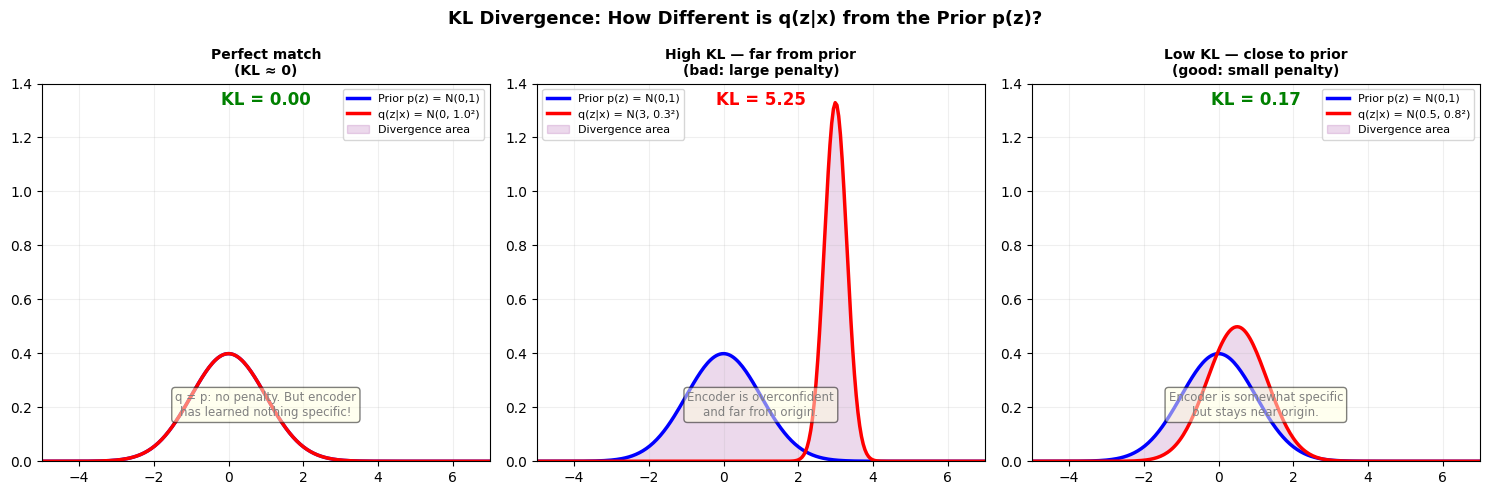

The KL term acts as a 'pressure' that squeezes encoder distributions back toward N(0,1).
This is what gives the latent space its nice structure for generation.


In [2]:
# ─────────────────────────────────────────────────
# Visualize KL Divergence between q(z|x) and p(z)
# ─────────────────────────────────────────────────

from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('KL Divergence: How Different is q(z|x) from the Prior p(z)?', 
             fontsize=13, fontweight='bold')

x = np.linspace(-6, 8, 300)
prior = stats.norm(0, 1)   # p(z) = N(0, 1)

scenarios = [
    {'mu': 0, 'sigma': 1.0,  'title': 'Perfect match\n(KL ≈ 0)',
     'comment': 'q = p: no penalty. But encoder\nhas learned nothing specific!'},
    {'mu': 3, 'sigma': 0.3,  'title': 'High KL — far from prior\n(bad: large penalty)',
     'comment': 'Encoder is overconfident\nand far from origin.'},
    {'mu': 0.5, 'sigma': 0.8,'title': 'Low KL — close to prior\n(good: small penalty)',
     'comment': 'Encoder is somewhat specific\nbut stays near origin.'},
]

for ax, s in zip(axes, scenarios):
    q = stats.norm(s['mu'], s['sigma'])
    
    # Compute KL divergence analytically
    kl = 0.5 * (s['mu']**2 + s['sigma']**2 - 2*np.log(s['sigma']) - 1)
    
    ax.plot(x, prior.pdf(x), 'b-', linewidth=2.5, label='Prior p(z) = N(0,1)')
    ax.plot(x, q.pdf(x), 'r-', linewidth=2.5, label=f'q(z|x) = N({s["mu"]}, {s["sigma"]:.1f}²)')
    ax.fill_between(x, prior.pdf(x), q.pdf(x), alpha=0.15, color='purple',
                    label='Divergence area')
    ax.set_title(s['title'], fontsize=10, fontweight='bold')
    ax.text(0.5, 0.98, f'KL = {kl:.2f}', transform=ax.transAxes,
            ha='center', va='top', fontsize=12,
            color='green' if kl < 0.5 else ('orange' if kl < 2 else 'red'),
            fontweight='bold')
    ax.text(0.5, 0.12, s['comment'], transform=ax.transAxes,
            ha='center', fontsize=8.5, color='gray',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    ax.set_xlim(-5, 7)
    ax.set_ylim(0, 1.4)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("The KL term acts as a 'pressure' that squeezes encoder distributions back toward N(0,1).")
print("This is what gives the latent space its nice structure for generation.")

---
<a id='7'></a>
## 7. The Reparameterization Trick

There's a subtle but critical problem: **we can't backpropagate through a random sampling operation.**

### The Problem

Our encoder outputs $\mu$ and $\sigma$, and we sample:

$$z \sim \mathcal{N}(\mu, \sigma^2)$$

But `sample()` is a non-differentiable operation. Gradients can't flow through it from the decoder loss back to the encoder parameters. Without gradients, we can't train the encoder.

### The Solution: Reparameterization

We rewrite the sampling as a **deterministic function** of $\mu$, $\sigma$, plus a separate random variable $\epsilon$:

$$\epsilon \sim \mathcal{N}(0, I)$$

$$z = \mu + \sigma \odot \epsilon$$

Now:
- The randomness is "outside" the network (in $\epsilon$)
- The computation graph through $\mu$ and $\sigma$ is fully differentiable
- Gradients flow from the decoder loss → $z$ → $\mu$ and $\sigma$ → encoder weights ✅

```
Before reparameterization:       After reparameterization:

Encoder → μ, σ                  Encoder → μ, σ
             ↓ (sample)                      ↓ (deterministic!)
             z ← N(μ, σ²)        z = μ + σ ⊙ ε ← N(0,I)
             ↓                              ↓
           Decoder              Decoder
             ↓                              ↓
           Loss                 Loss

🚫 Gradient blocked at sample   ✅ Gradient flows through z to μ, σ
```

This elegant trick is what makes VAE training possible, and it's widely used in probabilistic deep learning.

/var/folders/sr/rk5m4bnd15j7087y8pk1gn5m0000gp/T/ipykernel_49154/3173342214.py:43: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/samson.afolabi/Documents/DSR/Deep_Learning_Notebooks/deep_learning_311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


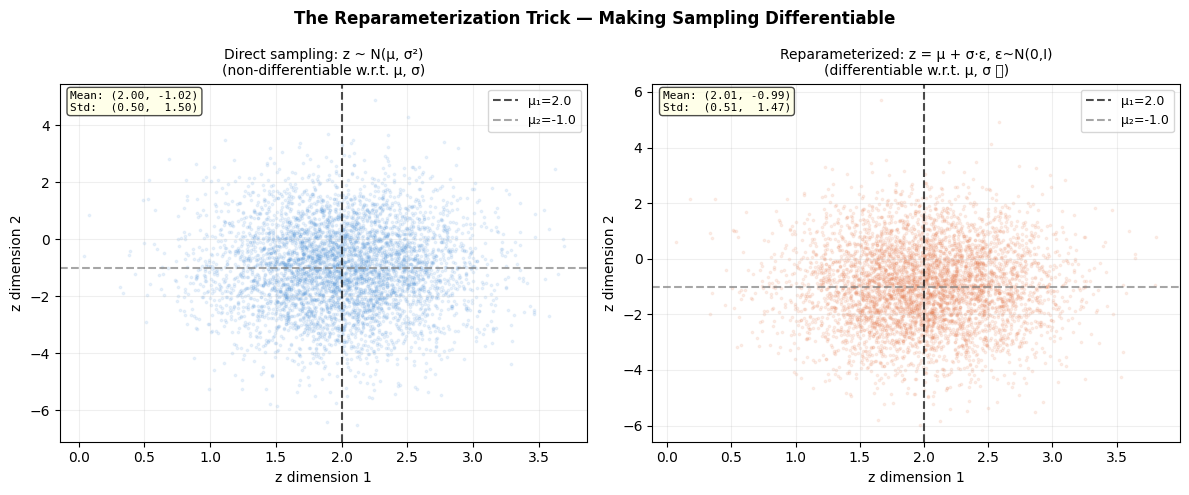

Both plots look IDENTICAL — the distributions are the same!
But only the right one allows gradients to flow back to the encoder.

Left  mean: (1.996, -1.025)
Right mean: (2.007, -0.990)


In [3]:
# ─────────────────────────────────────────────────
# Demonstrate reparameterization trick
# ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('The Reparameterization Trick — Making Sampling Differentiable', 
             fontsize=12, fontweight='bold')

# Show that z = μ + σ*ε has the same distribution as N(μ, σ²)
n_samples = 5000
mu    = np.array([2.0, -1.0])   # 2D example
sigma = np.array([0.5,  1.5])

# Method 1: direct sampling from N(μ, σ²)
z_direct = np.random.normal(mu, sigma, (n_samples, 2))

# Method 2: reparameterization z = μ + σ * ε, ε ~ N(0, I)
epsilon = np.random.randn(n_samples, 2)
z_reparam = mu + sigma * epsilon

colors = ['#4A90D9', '#E87040']

for ax, z, title, color in zip(axes, 
    [z_direct, z_reparam],
    ['Direct sampling: z ~ N(μ, σ²)\n(non-differentiable w.r.t. μ, σ)', 
     'Reparameterized: z = μ + σ·ε, ε~N(0,I)\n(differentiable w.r.t. μ, σ ✅)'],
    colors):

    ax.scatter(z[:, 0], z[:, 1], alpha=0.1, s=3, c=color)
    ax.axvline(mu[0], color='black', linestyle='--', alpha=0.7, label=f'μ₁={mu[0]}')
    ax.axhline(mu[1], color='gray',  linestyle='--', alpha=0.7, label=f'μ₂={mu[1]}')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('z dimension 1')
    ax.set_ylabel('z dimension 2')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    stats_text = (f'Mean: ({z[:,0].mean():.2f}, {z[:,1].mean():.2f})\n'
                  f'Std:  ({z[:,0].std():.2f},  {z[:,1].std():.2f})')
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8,
            va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("Both plots look IDENTICAL — the distributions are the same!")
print("But only the right one allows gradients to flow back to the encoder.")
print(f"\nLeft  mean: ({z_direct[:,0].mean():.3f}, {z_direct[:,1].mean():.3f})")
print(f"Right mean: ({z_reparam[:,0].mean():.3f}, {z_reparam[:,1].mean():.3f})")

---
<a id='8'></a>
## 8. Generating with a VAE

Once a VAE is trained, generation is simple:

1. Sample $z \sim \mathcal{N}(0, I)$ — a random point from the prior
2. Run the decoder: $\hat{x} = \text{Decoder}(z)$
3. Done — $\hat{x}$ is a new, realistic data sample

### Interpolation in Latent Space

One of the most striking capabilities of VAEs: because the latent space is continuous and smooth, you can **interpolate** between two data points:

```
z_A ──────────────────────────── z_B
 ↓          ↓         ↓           ↓
[Digit 3]  [3→7]  [between]   [Digit 7]
```

The intermediate points decode to meaningful, realistic intermediate states. This is impossible with a vanilla autoencoder (the path passes through dead zones).

### Arithmetic in Latent Space

VAE latent spaces often support semantic arithmetic (especially with more powerful architectures):

$$z_{\text{smiling woman}} - z_{\text{neutral woman}} + z_{\text{neutral man}} \approx z_{\text{smiling man}}$$

This suggests the latent space learns **disentangled** factors of variation.

### VAE Limitations

VAEs are powerful but have notable weaknesses:

1. **Blurry outputs:** The reconstruction loss (MSE) averages over all plausible completions, causing blurriness in image generation
2. **Posterior collapse:** For complex decoders, the model sometimes ignores the latent code and just uses the decoder as a language model
3. **Trade-off sensitivity:** Balancing reconstruction vs KL loss is delicate — $\beta$-VAE introduced a weighting parameter $\beta$ to control this

These limitations motivated the development of newer generative approaches — including diffusion models.

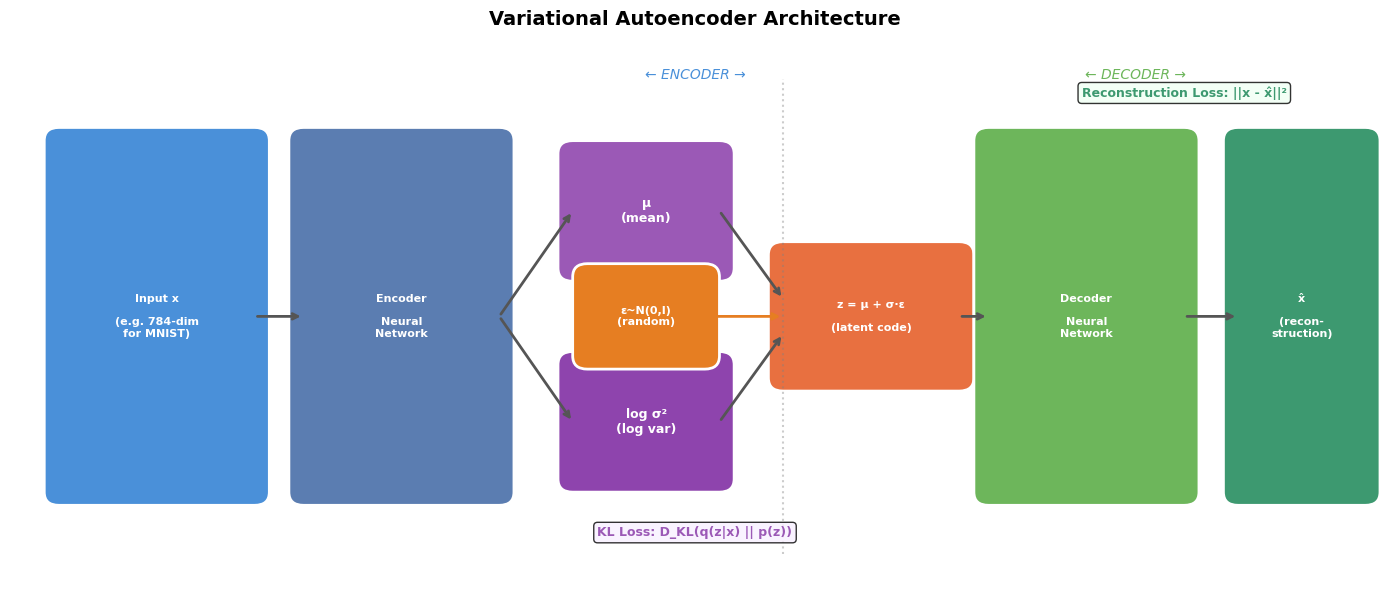

In [4]:
# ─────────────────────────────────────────────────
# Conceptual VAE architecture diagram
# ─────────────────────────────────────────────────

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('Variational Autoencoder Architecture', fontsize=14, fontweight='bold', pad=20)

def box(ax, x, y, w, h, color, text, fontsize=9, text_color='white'):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle="round,pad=0.15", facecolor=color, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=text_color, fontweight='bold', multialignment='center')

def arrow(ax, x1, y1, x2, y2, color='#555555', label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my+0.2, label, ha='center', fontsize=8, color=color, fontstyle='italic')

# Input
box(ax, 1.5, 3.0, 2.0, 4.0, '#4A90D9', 'Input x\n\n(e.g. 784-dim\nfor MNIST)',   fontsize=8)

# Encoder
box(ax, 4.0, 3.0, 2.0, 4.0, '#5B7DB1', 'Encoder\n\nNeural\nNetwork',            fontsize=8)

# Mu and log_var
box(ax, 6.5, 4.2, 1.5, 1.3, '#9B59B6', 'μ\n(mean)',   fontsize=9)
box(ax, 6.5, 1.8, 1.5, 1.3, '#8E44AD', 'log σ²\n(log var)', fontsize=9)

# Epsilon
box(ax, 6.5, 3.0, 1.2, 0.9, '#E67E22', 'ε~N(0,I)\n(random)', fontsize=8)

# Z sample
box(ax, 8.8, 3.0, 1.8, 1.4, '#E87040', 'z = μ + σ·ε\n\n(latent code)',   fontsize=8)

# Decoder
box(ax, 11.0, 3.0, 2.0, 4.0, '#6DB65B', 'Decoder\n\nNeural\nNetwork',          fontsize=8)

# Output
box(ax, 13.2, 3.0, 1.3, 4.0, '#3D9970', 'x̂\n\n(recon-\nstruction)', fontsize=8)

# Arrows
arrow(ax, 2.5, 3.0, 3.0, 3.0)
arrow(ax, 5.0, 3.0, 5.75, 4.2)
arrow(ax, 5.0, 3.0, 5.75, 1.8)
arrow(ax, 7.25, 4.2, 7.9, 3.2)
arrow(ax, 7.25, 1.8, 7.9, 2.8)
arrow(ax, 7.15, 3.0, 7.9, 3.0, '#E67E22')  # epsilon
arrow(ax, 9.7, 3.0, 10.0, 3.0)
arrow(ax, 12.0, 3.0, 12.55, 3.0)

# Loss annotations
ax.text(7.0, 0.5, 'KL Loss: D_KL(q(z|x) || p(z))', ha='center', fontsize=9,
        color='#9B59B6', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#F8F0FF', alpha=0.8))
ax.text(12.0, 5.5, 'Reconstruction Loss: ||x - x̂||²', ha='center', fontsize=9,
        color='#3D9970', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#F0FFF4', alpha=0.8))

ax.text(7.0, 5.7, '← ENCODER →', ha='center', fontsize=10, color='#4A90D9', fontstyle='italic')
ax.text(11.5, 5.7, '← DECODER →', ha='center', fontsize=10, color='#6DB65B', fontstyle='italic')
ax.axvline(8.8 - 0.9, color='gray', linestyle=':', alpha=0.4, ymin=0.05, ymax=0.95)

plt.tight_layout()
plt.show()

---
<a id='9'></a>
## 9. Diffusion Models — A Different Paradigm

Diffusion models have become the dominant paradigm for high-quality image generation (Stable Diffusion, DALL-E 3, Imagen, Midjourney). They are conceptually different from VAEs and extremely powerful.

### The Core Idea: Reversal of Destruction

Diffusion models are inspired by **non-equilibrium thermodynamics**. The idea:

> If we can learn to *reverse* the process of adding noise to an image, we can generate images by starting from pure noise and progressively denoising.

Introduced by **Sohl-Dickstein et al. (2015)** and made practical by **Ho et al. (DDPM, 2020)**.

### Two Processes

| Process | Direction | Description |
|---|---|---|
| **Forward process** $q$ | Data → Noise | Gradually add Gaussian noise over $T$ steps until image becomes pure noise |
| **Reverse process** $p_\theta$ | Noise → Data | Learn to denoise, step by step, until we recover a realistic image |

The forward process is **fixed and does not require learning**. The reverse process is **learned by a neural network**.

Think of it like this:
- Forward: Drop a photo into a vat of white paint, shaking it — eventually you get pure white noise
- Reverse: Start from white noise, and learn to reverse each "shake" to recover an image

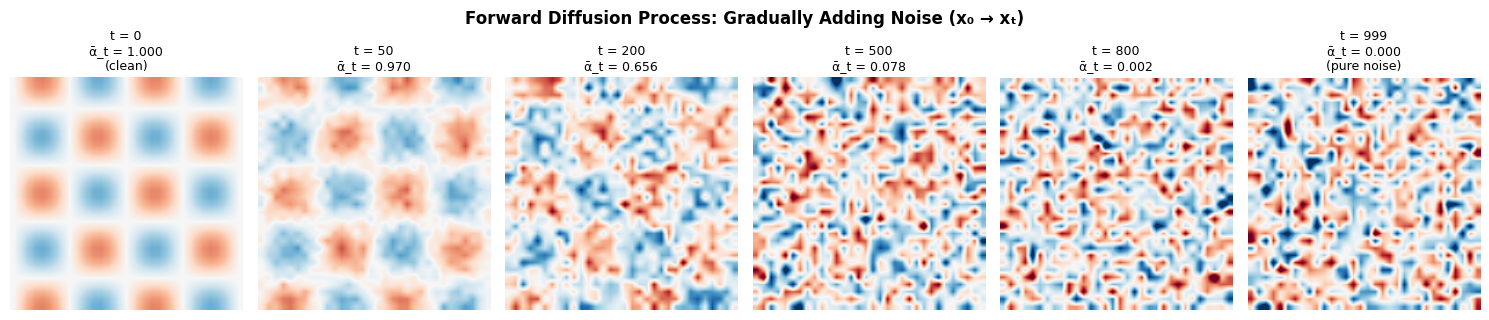

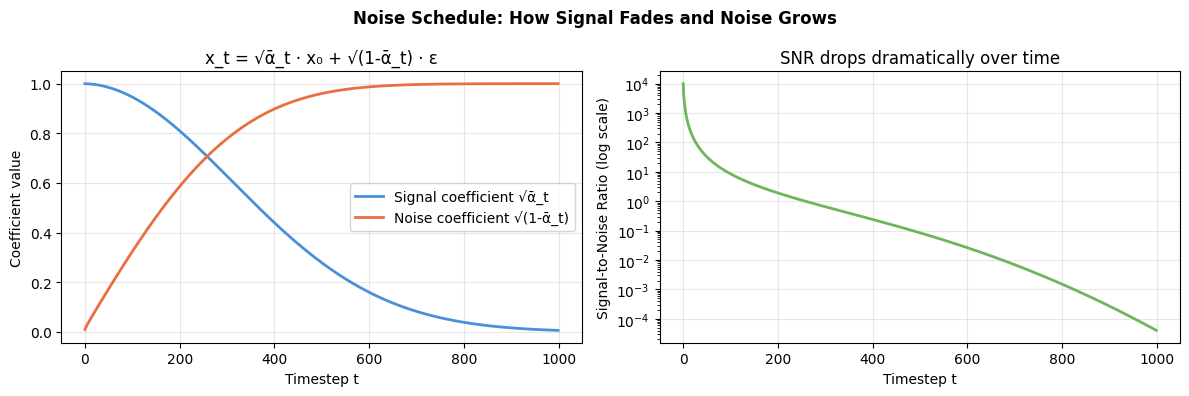

In [5]:
# ─────────────────────────────────────────────────
# Visualize the forward diffusion process
# Adding noise to a simple signal step by step
# ─────────────────────────────────────────────────

np.random.seed(7)

# Simulate a simple "image" as a 2D pattern (we'll use a sine pattern)
size = 32
xx, yy = np.meshgrid(np.linspace(0, 4*np.pi, size), np.linspace(0, 4*np.pi, size))
clean_image = np.sin(xx) * np.cos(yy)   # our "clean image" x_0

# Define noise schedule: beta_t controls how much noise is added at each step
T = 1000
beta = np.linspace(0.0001, 0.02, T)   # linear noise schedule
alpha = 1 - beta
alpha_bar = np.cumprod(alpha)           # ᾱ_t = ∏_{s=1}^{t} α_s

# Forward process: x_t = sqrt(ᾱ_t) * x_0 + sqrt(1 - ᾱ_t) * ε, ε ~ N(0, I)
# This is the closed-form expression — we can jump to any t directly!
def forward_diffusion(x0, t, alpha_bar):
    ab = alpha_bar[t]
    epsilon = np.random.randn(*x0.shape)
    x_t = np.sqrt(ab) * x0 + np.sqrt(1 - ab) * epsilon
    return x_t, epsilon

# Show images at different noise levels
timesteps_to_show = [0, 50, 200, 500, 800, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3.5))
fig.suptitle('Forward Diffusion Process: Gradually Adding Noise (x₀ → xₜ)', 
             fontsize=12, fontweight='bold')

for ax, t in zip(axes, timesteps_to_show):
    if t == 0:
        img = clean_image
        snr = float('inf')
    else:
        img, _ = forward_diffusion(clean_image, t, alpha_bar)
        snr = alpha_bar[t] / (1 - alpha_bar[t])
    
    ax.imshow(img, cmap='RdBu_r', vmin=-2, vmax=2, interpolation='bilinear')
    signal_label = f't = {t}\nᾱ_t = {alpha_bar[t]:.3f}'
    if t == 0:
        signal_label += '\n(clean)'
    elif t == 999:
        signal_label += '\n(pure noise)'
    ax.set_title(signal_label, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Also plot the noise schedule
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Noise Schedule: How Signal Fades and Noise Grows', fontsize=12, fontweight='bold')

t_range = np.arange(T)
ax1.plot(t_range, np.sqrt(alpha_bar),   color='#4A90D9', linewidth=2, label='Signal coefficient √ᾱ_t')
ax1.plot(t_range, np.sqrt(1-alpha_bar), color='#E87040', linewidth=2, label='Noise coefficient √(1-ᾱ_t)')
ax1.set_xlabel('Timestep t')
ax1.set_ylabel('Coefficient value')
ax1.set_title('x_t = √ᾱ_t · x₀ + √(1-ᾱ_t) · ε')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.semilogy(t_range, alpha_bar / (1 - alpha_bar + 1e-8), color='#6DB65B', linewidth=2)
ax2.set_xlabel('Timestep t')
ax2.set_ylabel('Signal-to-Noise Ratio (log scale)')
ax2.set_title('SNR drops dramatically over time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
<a id='10'></a>
## 10. The Forward Process: Adding Noise

The forward process is a fixed Markov chain that gradually adds Gaussian noise:

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t} \, x_{t-1}, \, \beta_t \mathbf{I})$$

Breaking this down:
- At each step, we slightly scale down the signal: $\sqrt{1 - \beta_t}$ is slightly less than 1
- We add a small amount of Gaussian noise with variance $\beta_t$
- $\beta_t$ is a **noise schedule** (small at start, larger later)

### The Key Mathematical Property

We can compute $x_t$ directly from $x_0$ in **one step** (no need to iterate through all $T$ steps):

$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t} \, x_0, \, (1 - \bar{\alpha}_t) \mathbf{I})$$

Where $\bar{\alpha}_t = \prod_{s=1}^{t}(1 - \beta_s)$ is the cumulative product of all $(1-\beta_s)$ up to step $t$.

**In simple terms:** $x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon$, where $\epsilon \sim \mathcal{N}(0, I)$.

This property is enormously useful for training: we can immediately compute the noisy version of an image at any timestep $t$ without running $t$ sequential steps.

### Behavior of $\bar{\alpha}_t$

- At $t = 0$: $\bar{\alpha}_0 = 1$ → $x_0 = x_0$ (clean image)
- At $t = T$: $\bar{\alpha}_T \approx 0$ → $x_T \approx \epsilon \sim \mathcal{N}(0, I)$ (pure noise)

The forward process is fully characterized by the noise schedule $\{\beta_t\}$, which is a design choice (linear, cosine, etc.).

---
<a id='11'></a>
## 11. The Reverse Process: Denoising

The reverse process is what makes diffusion models generative. It attempts to **undo the noise** step by step:

$$p_\theta(x_{t-1} | x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

A neural network $\theta$ parameterizes this distribution — given a noisy image $x_t$ at timestep $t$, it predicts the parameters of the distribution over the slightly-less-noisy $x_{t-1}$.

### Generation Procedure

```
x_T ~ N(0, I)    (pure noise)
  ↓  [Neural network denoises one step]
x_{T-1}          (slightly less noisy)
  ↓  [Neural network denoises one step]
x_{T-2}
  ↓
  ⋮  (repeat T times)
  ↓
x_0              (realistic generated image!)
```

### The Neural Network's Challenge

At each step, the network must answer:
> "Given this noisy image $x_t$ at noise level $t$, what is the most likely slightly-denoised version?"

This requires understanding:
- How much noise is present (given by $t$)
- What real images look like (learned from training data)
- Which direction to "push" the image to make it more realistic

### Architecture: The U-Net

The neural network used in diffusion models is typically a **U-Net** — an encoder-decoder architecture with skip connections:

```
  Input: x_t (noisy image) + t (timestep embedding)
  
  Encoder path (downsample):   [64] → [128] → [256] → [512]
  Bottleneck:                  [512] (with attention)
  Decoder path (upsample):     [512] → [256] → [128] → [64]
  Skip connections:            Each encoder level connects to decoder level
  
  Output: Predicted noise ε̂ (or predicted x_0)
```

The timestep $t$ is embedded using sinusoidal positional encodings (similar to Transformers) and injected into each layer via adaptive normalization.

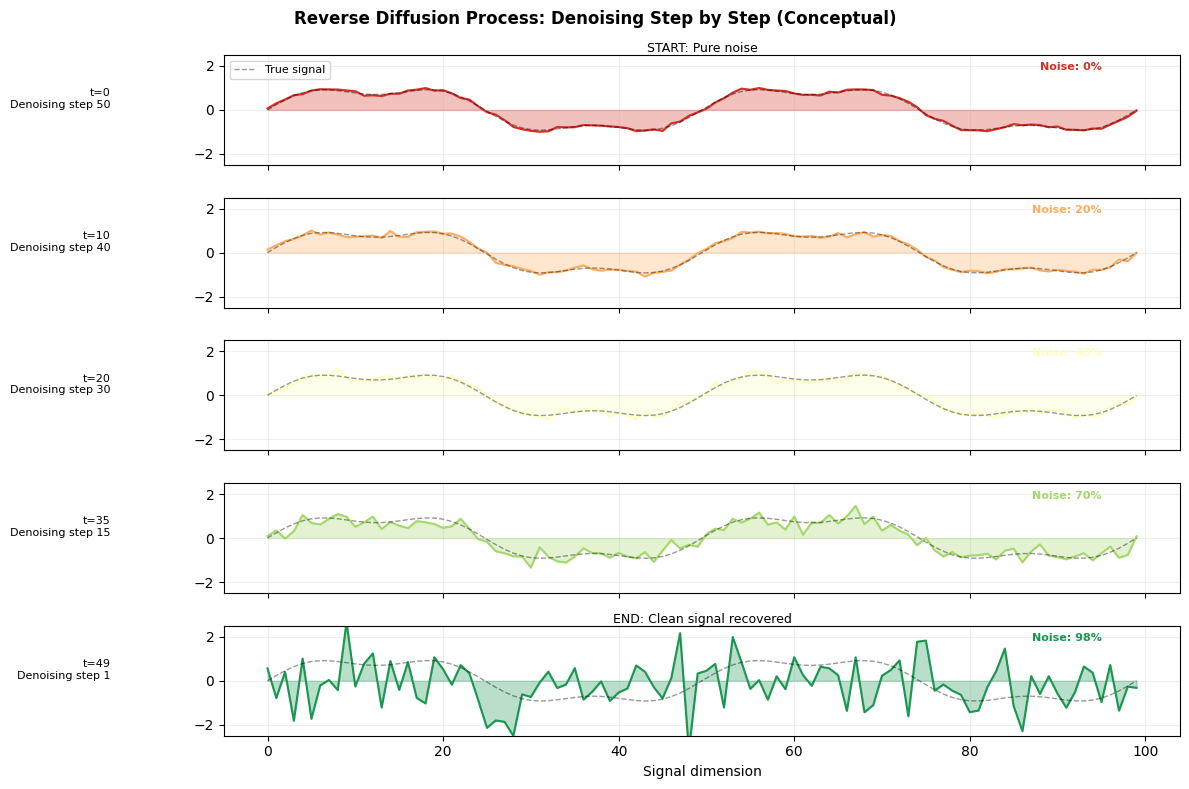

In [6]:
# ─────────────────────────────────────────────────
# Visualize the reverse denoising process conceptually
# We simulate what a trained denoiser would produce
# ─────────────────────────────────────────────────

np.random.seed(12)

# Simulate a 1D "clean signal" (simplified)
n = 100
clean = np.sin(np.linspace(0, 4*np.pi, n)) + 0.3 * np.sin(np.linspace(0, 12*np.pi, n))

# Forward: add noise to get x_T
T_steps = 50
beta_sim = np.linspace(0.01, 0.3, T_steps)
alpha_sim = 1 - beta_sim
ab_sim = np.cumprod(alpha_sim)

# Start from pure noise
x_t = np.random.randn(n)

# "Simulate" denoising: blend gradually back toward clean signal
# (In reality, a trained neural network does this)
denoising_trajectory = [x_t.copy()]
for step in range(T_steps - 1, -1, -1):
    # Simulated denoiser: approximate posterior mean
    t_frac = step / T_steps
    ab = ab_sim[step]
    # Approximate x_0 from x_t (oracle — uses true clean signal for visualization)
    x0_pred = (x_t - np.sqrt(1 - ab) * np.random.randn(n) * 0.3) / np.sqrt(ab)
    # Blend: at early steps more noise, at late steps more signal
    x_t = t_frac * x_t + (1 - t_frac) * clean + np.random.randn(n) * (0.05 + t_frac * 0.15)
    denoising_trajectory.append(x_t.copy())

# Plot selected steps from the reverse process
steps_to_show = [0, 10, 20, 35, 49]
fig, axes = plt.subplots(len(steps_to_show), 1, figsize=(12, 8), sharex=True)
fig.suptitle('Reverse Diffusion Process: Denoising Step by Step (Conceptual)', 
             fontsize=12, fontweight='bold')

cmap_colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(steps_to_show)))

for idx, (ax, step) in enumerate(zip(axes, steps_to_show)):
    trajectory_idx = len(denoising_trajectory) - 1 - step
    signal = denoising_trajectory[min(trajectory_idx, len(denoising_trajectory)-1)]
    
    ax.fill_between(range(n), signal, alpha=0.3, color=cmap_colors[idx])
    ax.plot(signal, color=cmap_colors[idx], linewidth=1.5)
    ax.plot(clean, color='black', linewidth=1, linestyle='--', alpha=0.4, label='True signal')
    
    reverse_step = T_steps - step
    ax.set_ylabel(f't={step}\nDenoising step {reverse_step}', fontsize=8, rotation=0, 
                  ha='right', labelpad=60)
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelbottom=False)
    
    noise_level = step / T_steps
    ax.text(95, 1.8, f'Noise: {noise_level:.0%}', ha='right', fontsize=8, 
            color=cmap_colors[idx], fontweight='bold')

axes[0].set_title('START: Pure noise', fontsize=9, pad=2)
axes[-1].set_title('END: Clean signal recovered', fontsize=9, pad=2)
axes[0].legend(loc='upper left', fontsize=8)
axes[-1].tick_params(labelbottom=True)
axes[-1].set_xlabel('Signal dimension')

plt.tight_layout()
plt.show()

---
<a id='12'></a>
## 12. What the Network Actually Learns

### The Training Objective

Here is the elegant simplification that makes DDPM training practical. The network is trained to **predict the noise** $\epsilon$ that was added to $x_0$ to produce $x_t$:

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{t, x_0, \epsilon} \left[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \right]$$

That's it — **mean squared error between the true noise and the predicted noise.** Despite its simplicity, this objective produces state-of-the-art generative models.

### Training algorithm

```
Repeat until converged:
  1. Sample a clean image x_0 from the training dataset
  2. Sample a random timestep t ~ Uniform(1, T)
  3. Sample noise ε ~ N(0, I)
  4. Compute x_t = √ᾱ_t · x_0 + √(1-ᾱ_t) · ε   (forward process, closed form)
  5. Predict: ε̂ = neural_network(x_t, t)
  6. Loss = ||ε - ε̂||²
  7. Backpropagate and update weights
```

### Inference/sampling algorithm

```
x_T ~ N(0, I)     (start from pure noise)
for t = T, T-1, ..., 1:
  ε̂ = neural_network(x_t, t)     (predict the noise)
  x_{t-1} = (x_t - β_t/√(1-ᾱ_t) · ε̂) / √α_t + σ_t · z    (denoise one step)
  # z ~ N(0, I) for t > 1, else z = 0
return x_0
```

### Why does predicting noise work?

If you can predict what noise was added, you can remove it. And if you can remove noise incrementally over many steps, you gradually refine a noisy sample into a realistic one. The network becomes an expert at the question: **"Does this look like real data, and if not, what noise should I remove?"** — which is equivalent to learning the data distribution.

### Classifier-Free Guidance (CFG)

For conditional generation (e.g., "generate a cat" or "generate based on this text prompt"), diffusion models use **Classifier-Free Guidance**:
- Train the model both with and without conditioning information
- At inference, blend the conditional and unconditional predictions:

$$\hat{\epsilon} = \epsilon_{\text{uncond}} + w \cdot (\epsilon_{\text{cond}} - \epsilon_{\text{uncond}})$$

The guidance weight $w$ controls the trade-off between diversity and fidelity. Higher $w$ = more adherence to the condition but less diversity.

/var/folders/sr/rk5m4bnd15j7087y8pk1gn5m0000gp/T/ipykernel_49154/967909155.py:53: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/samson.afolabi/Documents/DSR/Deep_Learning_Notebooks/deep_learning_311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


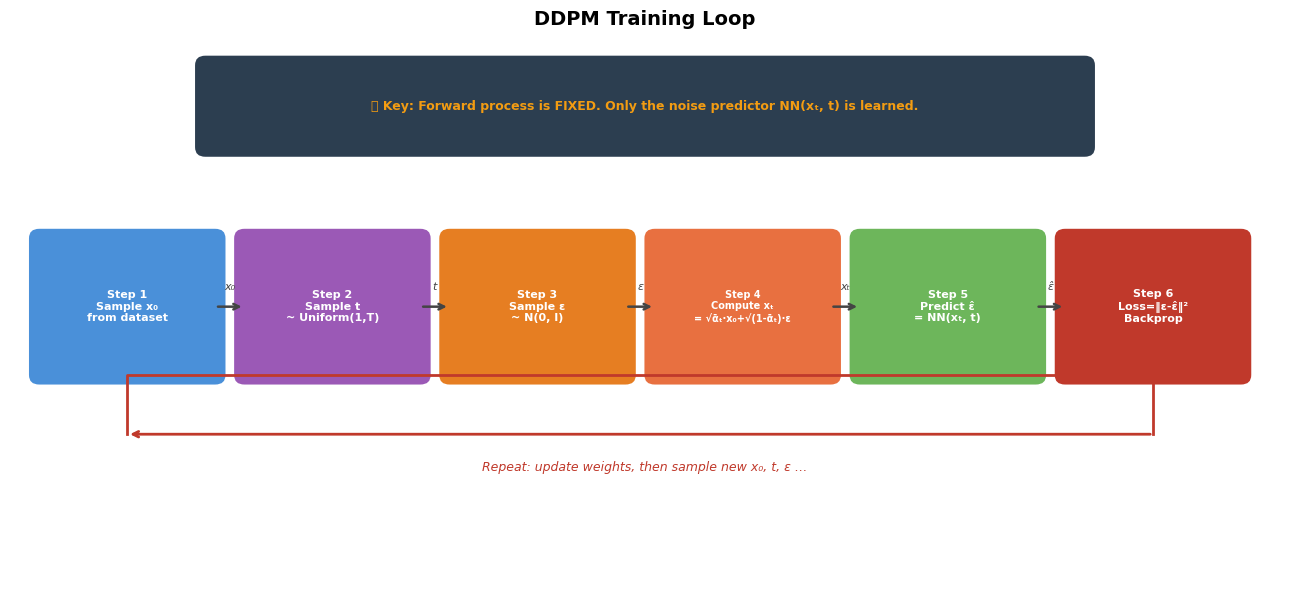

In [7]:
# ─────────────────────────────────────────────────
# Visualize the diffusion training loop
# ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('DDPM Training Loop', fontsize=14, fontweight='bold')

def rounded_box(ax, cx, cy, w, h, color, text, fs=9, alpha=1.0, tc='white'):
    rect = mpatches.FancyBboxPatch((cx-w/2, cy-h/2), w, h,
        boxstyle="round,pad=0.12", facecolor=color, edgecolor='white', 
        linewidth=2, alpha=alpha)
    ax.add_patch(rect)
    ax.text(cx, cy, text, ha='center', va='center', fontsize=fs,
            color=tc, fontweight='bold', multialignment='center')

def arr(ax, x1, y1, x2, y2, lbl='', color='#444'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if lbl:
        ax.text((x1+x2)/2, (y1+y2)/2+0.18, lbl, ha='center', fontsize=8,
                color=color, fontstyle='italic')

# Step boxes
rounded_box(ax, 1.2, 3.0, 1.8, 1.5, '#4A90D9', 'Step 1\nSample x₀\nfrom dataset',        fs=8)
rounded_box(ax, 3.3, 3.0, 1.8, 1.5, '#9B59B6', 'Step 2\nSample t\n~ Uniform(1,T)',       fs=8)
rounded_box(ax, 5.4, 3.0, 1.8, 1.5, '#E67E22', 'Step 3\nSample ε\n~ N(0, I)',            fs=8)
rounded_box(ax, 7.5, 3.0, 1.8, 1.5, '#E87040', 'Step 4\nCompute xₜ\n= √ᾱₜ·x₀+√(1-ᾱₜ)·ε', fs=7)
rounded_box(ax, 9.6, 3.0, 1.8, 1.5, '#6DB65B', 'Step 5\nPredict ε̂\n= NN(xₜ, t)',        fs=8)
rounded_box(ax, 11.7, 3.0, 1.8, 1.5,'#C0392B', 'Step 6\nLoss=‖ε-ε̂‖²\nBackprop',        fs=8)

arr(ax, 2.1, 3.0, 2.4, 3.0, 'x₀')
arr(ax, 4.2, 3.0, 4.5, 3.0, 't')
arr(ax, 6.3, 3.0, 6.6, 3.0, 'ε')
arr(ax, 8.4, 3.0, 8.7, 3.0, 'xₜ')
arr(ax, 10.5,3.0, 10.8,3.0, 'ε̂')

# Loop back arrow
ax.annotate('', xy=(1.2, 1.6), xytext=(11.7, 1.6),
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=2,
                           connectionstyle='arc3,rad=0'))
ax.plot([1.2, 1.2, 11.7, 11.7], [1.6, 2.25, 2.25, 1.6], color='#C0392B', lw=2)
ax.text(6.5, 1.2, 'Repeat: update weights, then sample new x₀, t, ε …', ha='center',
        fontsize=9, color='#C0392B', fontstyle='italic')

# Key insight box
rounded_box(ax, 6.5, 5.2, 9.0, 0.9, '#2C3E50', 
            '🔑 Key: Forward process is FIXED. Only the noise predictor NN(xₜ, t) is learned.',
            fs=9, tc='#F39C12')

plt.tight_layout()
plt.show()

---
<a id='13'></a>
## 13. VAEs vs Diffusion: Trade-offs

Both VAEs and diffusion models are powerful generative frameworks, but they have very different characteristics:

| Property | VAE | Diffusion Model |
|---|---|---|
| **Generation speed** | ⚡ Very fast (one decoder pass) | 🐌 Slow (T=50–1000 steps) |
| **Sample quality** | 🟡 Good, often blurry | 🏆 State-of-the-art |
| **Diversity** | 🟡 Moderate | ✅ High |
| **Latent space** | ✅ Explicit, structured | ❌ No compact latent space* |
| **Editability** | ✅ Easy (manipulate z) | 🟡 More complex |
| **Training stability** | ✅ Very stable | ✅ Stable |
| **Training complexity** | 🟡 Moderate (balance KL + recon) | ✅ Simple (just MSE on noise) |
| **Memory during training** | 🟡 Moderate | 🟡 Moderate |
| **Conditional generation** | 🟡 Possible | ✅ Excellent (CFG) |

*Latent Diffusion Models (LDM) solve this by diffusing in a VAE's latent space!

### The Best of Both Worlds: Latent Diffusion Models

Modern image generators like **Stable Diffusion** combine both ideas:

1. Train a VAE to compress images into a compact latent space (e.g., 512×512 image → 64×64 latent)
2. Train a diffusion model to operate **in the latent space** instead of pixel space
3. Decode samples from the latent space using the VAE decoder

Benefits: 
- ~8× faster than pixel-space diffusion (smaller spatial dimensions)
- Still produces high-quality, diverse samples
- The latent space provides some structure for editing

```
Text prompt
    ↓ CLIP encoder
Text embedding
    ↓ 
Diffusion model ← noise (operating in VAE latent space, 64×64)
    ↓ (T denoising steps with cross-attention on text)
Latent z (64×64)
    ↓ VAE Decoder
Image (512×512)
```

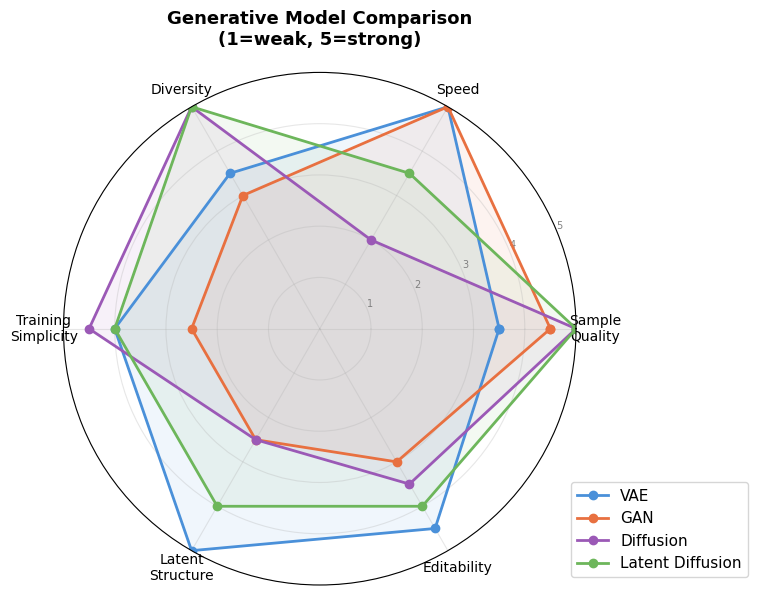

Note: GAN scores are included for context — GANs are another major generative family
(adversarial training) not covered in depth in this notebook.


In [8]:
# ─────────────────────────────────────────────────
# Radar chart: comparing generative model families
# ─────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

categories = ['Sample\nQuality', 'Speed', 'Diversity', 
              'Training\nSimplicity', 'Latent\nStructure', 'Editability']
N = len(categories)

models = {
    'VAE':              [3.5, 5.0, 3.5, 4.0, 5.0, 4.5],
    'GAN':              [4.5, 5.0, 3.0, 2.5, 2.5, 3.0],
    'Diffusion':        [5.0, 2.0, 5.0, 4.5, 2.5, 3.5],
    'Latent Diffusion': [5.0, 3.5, 5.0, 4.0, 4.0, 4.0],
}
colors = ['#4A90D9', '#E87040', '#9B59B6', '#6DB65B']

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_title('Generative Model Comparison\n(1=weak, 5=strong)', 
             size=13, fontweight='bold', pad=20)

for (name, values), color in zip(models.items(), colors):
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=7, color='gray')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', bbox_to_anchor=(1.35, 0.0), fontsize=11)

plt.tight_layout()
plt.show()

print("Note: GAN scores are included for context — GANs are another major generative family")
print("(adversarial training) not covered in depth in this notebook.")

---
<a id='14'></a>
## 14. The Broader Generative Model Landscape

VAEs and Diffusion models sit within a broader ecosystem of generative models. Here's how they fit:

### Family Tree of Deep Generative Models

```
Deep Generative Models
│
├── Likelihood-based
│   ├── Autoregressive Models  — model p(x) as ∏ p(xᵢ | x₁,...,xᵢ₋₁)
│   │   Examples: PixelCNN, GPT, WaveNet
│   │   Pros: exact likelihood; Cons: slow generation (sequential)
│   │
│   ├── Variational Autoencoders (VAEs)
│   │   Maximize a lower bound (ELBO) on log p(x)
│   │   Pros: fast, structured latent space; Cons: blurry samples
│   │
│   ├── Normalizing Flows
│   │   Invertible transformations: z ↔ x with exact likelihood
│   │   Pros: exact likelihood; Cons: architecture constraints
│   │
│   └── Diffusion Models
│       Denoise samples from N(0,I) iteratively
│       Pros: best quality; Cons: slow sampling
│
└── Implicit (no explicit likelihood)
    └── GANs (Generative Adversarial Networks)
        Generator vs Discriminator game
        Pros: fast, sharp samples; Cons: training instability, mode collapse
```

### Current State of the Field (2024–2025)

| Domain | Dominant approach |
|---|---|
| **Image generation** | Latent Diffusion (Stable Diffusion, DALL-E 3, Flux) |
| **Video generation** | Diffusion + Transformers (Sora, Gen-3) |
| **Text generation** | Autoregressive Transformers (GPT-4, Claude, Llama) |
| **Audio/music** | Diffusion (AudioLDM) + Autoregressive (AudioPaLM) |
| **3D / molecules** | Diffusion models (e.g., DiffSBDD for drug design) |
| **Representation learning** | VAEs, Contrastive methods (CLIP, SimCLR) |

### Emerging Trends

- **Flow Matching:** A cleaner mathematical framework that learns straight-line trajectories instead of diffusion paths — faster inference than DDPM
- **Consistency Models:** Can generate in 1–4 steps instead of 50–1000
- **Masked Diffusion:** Diffusion applied to discrete tokens (text, code) rather than continuous images
- **World Models:** Generative models of entire environments for reinforcement learning

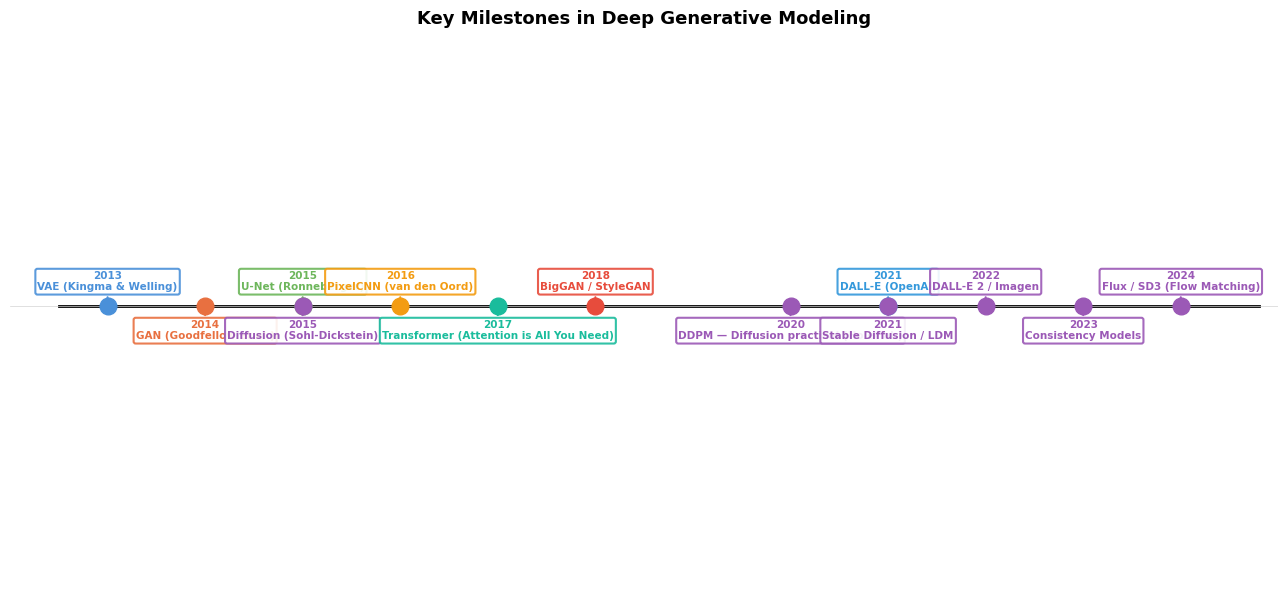

In [9]:
# ─────────────────────────────────────────────────
# Timeline of key generative model milestones
# ─────────────────────────────────────────────────

milestones = [
    (2013, 'VAE (Kingma & Welling)',           '#4A90D9'),
    (2014, 'GAN (Goodfellow et al.)',           '#E87040'),
    (2015, 'U-Net (Ronneberger)',               '#6DB65B'),
    (2015, 'Diffusion (Sohl-Dickstein)',        '#9B59B6'),
    (2016, 'PixelCNN (van den Oord)',           '#F39C12'),
    (2017, 'Transformer (Attention is All You Need)', '#1ABC9C'),
    (2018, 'BigGAN / StyleGAN',                '#E74C3C'),
    (2020, 'DDPM — Diffusion practical (Ho et al.)',  '#9B59B6'),
    (2021, 'DALL-E (OpenAI)',                  '#3498DB'),
    (2021, 'Stable Diffusion / LDM',           '#9B59B6'),
    (2022, 'DALL-E 2 / Imagen',               '#9B59B6'),
    (2023, 'Consistency Models',               '#9B59B6'),
    (2024, 'Flux / SD3 (Flow Matching)',        '#9B59B6'),
]

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_title('Key Milestones in Deep Generative Modeling', fontsize=13, fontweight='bold')

years = [m[0] for m in milestones]
ax.set_xlim(2012, 2025)
ax.set_ylim(-0.5, len(milestones) + 0.5)
ax.axhline(len(milestones)/2, color='lightgray', linewidth=0.5)

# Main timeline
ax.plot([2012.5, 2024.8], [len(milestones)/2]*2, 'k-', linewidth=2, zorder=1)

for i, (year, label, color) in enumerate(milestones):
    y_pos = len(milestones) - i - 0.5
    # Dot on timeline
    timeline_y = len(milestones)/2
    ax.plot(year, timeline_y, 'o', color=color, markersize=12, zorder=3)
    
    # Alternate above/below
    if i % 2 == 0:
        text_y = timeline_y + 0.8 + (i // 2) * 0.0
        va = 'bottom'
        dy = 0.3
    else:
        text_y = timeline_y - 0.8 - (i // 2) * 0.0
        va = 'top'
        dy = -0.3
    
    ax.annotate('', xy=(year, timeline_y + (0.3 if i%2==0 else -0.3)), 
                xytext=(year, timeline_y),
                arrowprops=dict(arrowstyle='-', color=color, lw=1.5))
    ax.text(year, timeline_y + (0.35 if i%2==0 else -0.35),
            f'{year}\n{label}', ha='center', va=va, fontsize=7.5,
            color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                     edgecolor=color, alpha=0.9, linewidth=1.5))

ax.axis('off')
plt.tight_layout()
plt.show()

---
<a id='15'></a>
## 15. Summary & Key Takeaways

### Generative Models — Big Picture

| Concept | One-line summary |
|---|---|
| **Generative vs Discriminative** | Discriminative: $p(y|x)$. Generative: $p(x)$ — model the data distribution itself |
| **Latent space** | Low-dimensional representation capturing essential structure of data |
| **Autoencoder** | Compress + reconstruct; good for features, not generation (unstructured latent space) |
| **VAE** | Encoder outputs distributions (μ, σ); KL regularizes latent space toward N(0,I) |
| **VAE loss** | Reconstruction loss + KL divergence (the ELBO) — two competing forces |
| **Reparameterization** | z = μ + σ·ε allows gradients to flow through sampling |
| **VAE generation** | Sample z ~ N(0,I), run decoder → new sample |
| **Diffusion — forward** | Fixed process: add noise gradually until x_T ≈ N(0,I) |
| **Diffusion — reverse** | Learned: neural network denoises step by step from noise to data |
| **Diffusion objective** | Predict the noise ε added at each step — surprisingly simple MSE |
| **CFG** | Condition + guidance weight enables text-to-image control |
| **Latent Diffusion** | Diffuse in VAE latent space → fast + high quality (Stable Diffusion) |